# SSP2-4.5 vs SSP5-8.5 Divergence Study -- Seville (2026-2100)

Answers a question raised while interpreting `seville_cmip6_projection_eda.ipynb`'s "Reading the
gap" section: near-term (2026-2045), a single-realization comparison of SSP2-4.5 against SSP5-8.5
mostly reflects internal-variability noise, not the actual emissions-scenario difference (see
`documentation/SSP_Scenario_Uncertainty_Interpretation.md` for the full reasoning and literature
sources -- Hawkins & Sutton 2009, O'Neill et al. 2021). This notebook extends both scenarios'
`cmcc_esm2` pulls out to **2100** (the full CDS-published ScenarioMIP horizon for this
model/experiment, confirmed against the live CDS constraints endpoint before pulling) and asks
directly: **at what point, if any, does the SSP2-4.5 vs SSP5-8.5 gap become larger than the noise
floor of a single model run?**

**Source data:** both scenarios' raw pulls were extended from their original 2026-2045 (SSP2-4.5)
and 2026-2061 (SSP5-8.5) windows out to 2026-2100
(`scripts/extend_cmip6_projections_ssp245_2046_2100.py`,
`scripts/extend_cmip6_projections_ssp585_2062_2100.py`), then bias-corrected against ERA5 using the
same Equidistant CDF Matching machinery and the same reused `cmcc_esm2` historical run as every
other notebook in this project (`scripts/bias_correct_divergence_study_seville.py`).

**What this notebook does NOT do:** rebuild the full indicator suite (heatwaves, tropical nights,
wet-day stats) for the extended window -- that would mean redoing all six existing notebooks' every
panel, a much larger undertaking than the time available. This is a focused, separate piece
answering one specific question -- five indicators covering Seville's whole heat-escalation ->
drought -> fire-risk story (`tas_mean`, `tmax_mean`, `precip_total`, `min_spi3`, `days_fwi_gt30`),
each plotted and tested for divergence, computed via standalone scripts
(`scripts/compute_divergence_spi3.py`, `scripts/compute_divergence_fwi_seville.py`) that reuse the
existing SPI-3/FWI methodology rather than rebuilding either notebook.

**Note on what actually motivated the extension to 2100:** it wasn't a check of "was 2061 far
enough" -- the real trigger was noticing, while extending, that the temperature signal starts
building *immediately after* the original notebooks' own 2026-2045 window, not at some arbitrary
later point. Section 8 below shows this directly: the sign of the SSP5-8.5-vs-SSP2-4.5 gap is
actually backwards within 2026-2045 (pure noise), then flips and starts climbing the very next
decade.

**Caveats carried over unchanged from every other projection notebook in this project:** single
model, single realization each (`cmcc_esm2` published only `r1i1p1f1` for both scenarios --
confirmed via CDS/ESGF metadata, see the uncertainty-interpretation doc), no ensemble spread.
Everything below is *directional risk under two plausible pathways*, not a calibrated forecast --
and this notebook's whole point is to characterize how much of any apparent gap is scenario signal
vs. single-run noise, not to pretend that question away.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

pd.set_option("display.width", 140)

SSP245_CSV = Path("../SSP2-4.5/data/seville_cmip6_cmcc_esm2_ssp245_2026_2100_biascorrected.csv")
SSP585_CSV = Path("../SSP5-8.5/data/seville_cmip6_cmcc_esm2_ssp585_2026_2100_biascorrected.csv")
ERA5_ANNUAL_CSV = Path("../../Historical/eda_outputs/seville/annual_summary.csv")
FIG_DIR = Path("../figures")
OUT_DIR = Path("../eda_outputs")
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print("SSP2-4.5 file exists:", SSP245_CSV.exists())
print("SSP5-8.5 file exists:", SSP585_CSV.exists())
print("ERA5 annual file exists:", ERA5_ANNUAL_CSV.exists())

SSP2-4.5 file exists: True
SSP5-8.5 file exists: True
ERA5 annual file exists: True


## 2. Load both scenarios and build annual summaries

Both bias-corrected daily files already carry `year`/`month` columns from
`cmip6_grid_processing.grid_average_daily()`. `precip_total` is summed per year (cumulative);
temperature indicators are averaged per year, matching every other notebook's convention.

In [2]:
ssp245_daily = pd.read_csv(SSP245_CSV, index_col=0, parse_dates=True)
ssp585_daily = pd.read_csv(SSP585_CSV, index_col=0, parse_dates=True)
era5_annual = pd.read_csv(ERA5_ANNUAL_CSV, index_col="year")

def annual_summary(daily):
    return pd.DataFrame({
        "tas_mean": daily.groupby("year")["tmean_c"].mean(),
        "tmax_mean": daily.groupby("year")["tmax_c"].mean(),
        "tmin_mean": daily.groupby("year")["tmin_c"].mean(),
        "precip_total": daily.groupby("year")["precip_mm_day"].sum(),
    })

ann245 = annual_summary(ssp245_daily)
ann585 = annual_summary(ssp585_daily)

print(f"SSP2-4.5: {len(ann245)} years, {ann245.index.min()}-{ann245.index.max()}")
print(f"SSP5-8.5: {len(ann585)} years, {ann585.index.min()}-{ann585.index.max()}")
ann245.describe().round(2)

SSP2-4.5: 75 years, 2026-2100
SSP5-8.5: 75 years, 2026-2100


,tas_mean,tmax_mean,tmin_mean,precip_total
count,75.00,75.00,75.00,75.00
mean,21.44,25.90,16.84,464.04
std,1.10,1.14,1.21,157.78
min,19.41,23.53,14.50,172.55
25%,20.62,25.01,15.89,339.17
50%,21.47,25.95,16.95,444.10
75%,22.22,26.73,17.82,570.78
max,23.31,27.95,19.06,822.92


## 2.1 Load additional indicators: `min_spi3` and `days_fwi_gt30`

Completes Seville's headline story (heat escalation -> drought -> more fire risk) with the two
remaining indicators, computed separately (`scripts/compute_divergence_spi3.py`,
`scripts/compute_divergence_fwi_seville.py`) since both need machinery beyond a simple groupby --
`min_spi3` needs the fixed ERA5 1990-2020 gamma-distribution fit reused from
`Calculating_SPI_for_Seville_Projection.ipynb`; `days_fwi_gt30` needs the full CEMS-warm-started
FWI computation reused from `FWI_projections_Seville_2026_2045.ipynb`. Both scripts read the same
bias-corrected 2026-2100 files this notebook already uses.

In [3]:
EDA_OUT = Path("../eda_outputs")

spi3_245 = pd.read_csv(EDA_OUT / "seville_ssp245_min_spi3_annual_2026_2100.csv", index_col="year")["min_spi3"]
spi3_585 = pd.read_csv(EDA_OUT / "seville_ssp585_min_spi3_annual_2026_2100.csv", index_col="year")["min_spi3"]
fwi_245 = pd.read_csv(EDA_OUT / "seville_ssp245_fwi_annual_2026_2100.csv", index_col=0)["days_fwi_gt30"]
fwi_585 = pd.read_csv(EDA_OUT / "seville_ssp585_fwi_annual_2026_2100.csv", index_col=0)["days_fwi_gt30"]
fwi_245.index = fwi_245.index.astype(int)
fwi_585.index = fwi_585.index.astype(int)

ann245["min_spi3"] = spi3_245
ann585["min_spi3"] = spi3_585
ann245["days_fwi_gt30"] = fwi_245
ann585["days_fwi_gt30"] = fwi_585

print("min_spi3 and days_fwi_gt30 joined into ann245/ann585")
ann245[["min_spi3", "days_fwi_gt30"]].describe().round(2)

min_spi3 and days_fwi_gt30 joined into ann245/ann585


,min_spi3,days_fwi_gt30
count,75.00,75.00
mean,-2.26,145.73
std,0.89,24.98
min,-4.75,77.00
25%,-2.85,130.50
50%,-2.19,143.00
75%,-1.70,163.00
max,-0.48,213.00


## 3. Full-length comparison, 2026-2100

Thin lines are the raw annual values (mostly noise at this scale); thick lines are a 10-year
centered rolling mean, which is what actually shows the underlying signal separating from -- or
staying inside -- the year-to-year scatter. The dotted vertical line marks 2045, where the original
`seville_cmip6_projection_eda.ipynb` notebooks' own analysis window ends -- the point this notebook
exists to look past.

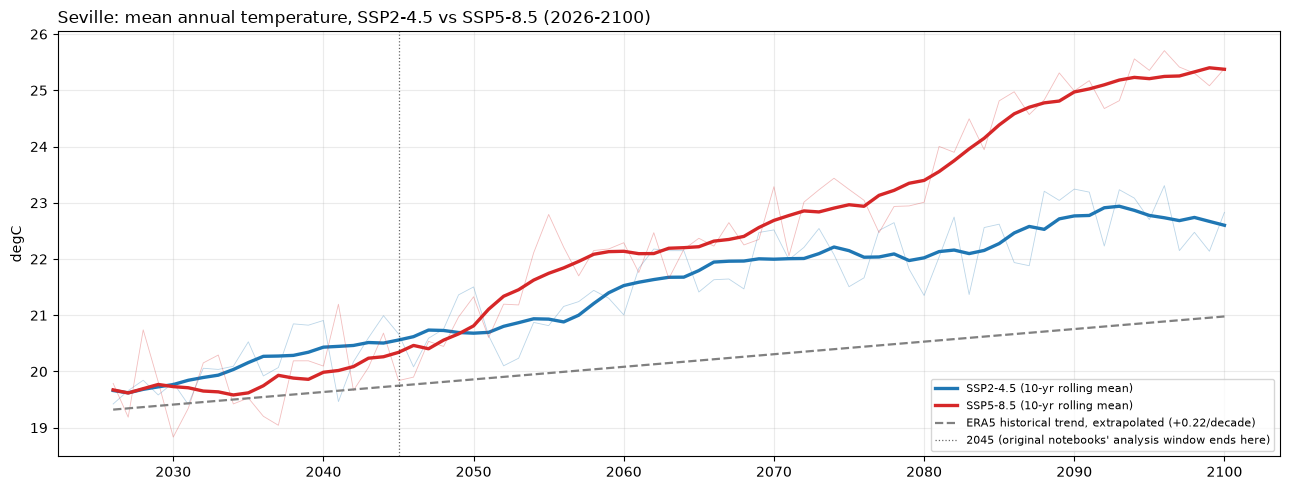

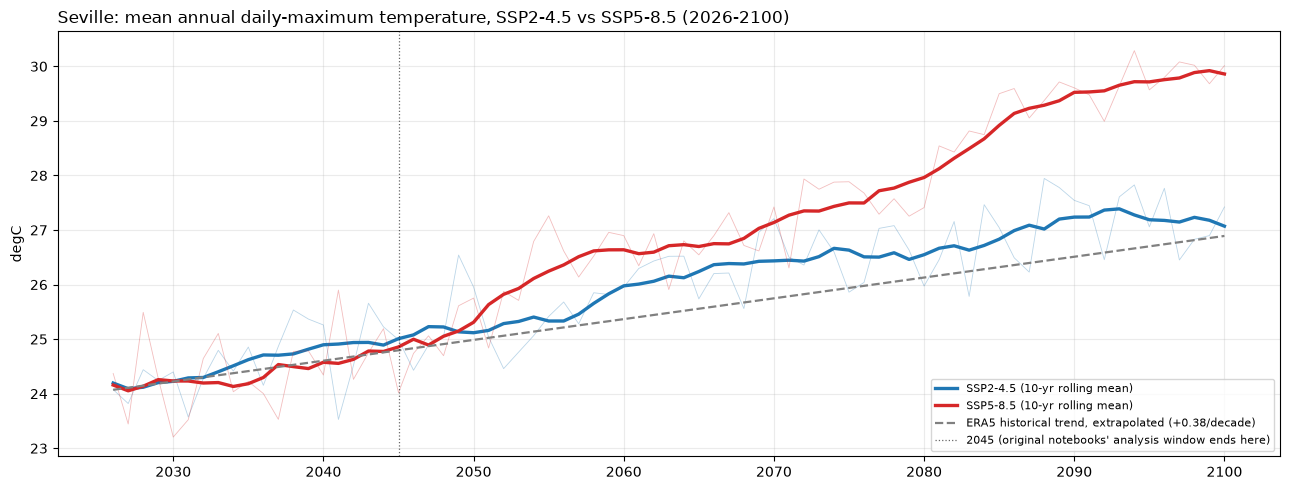

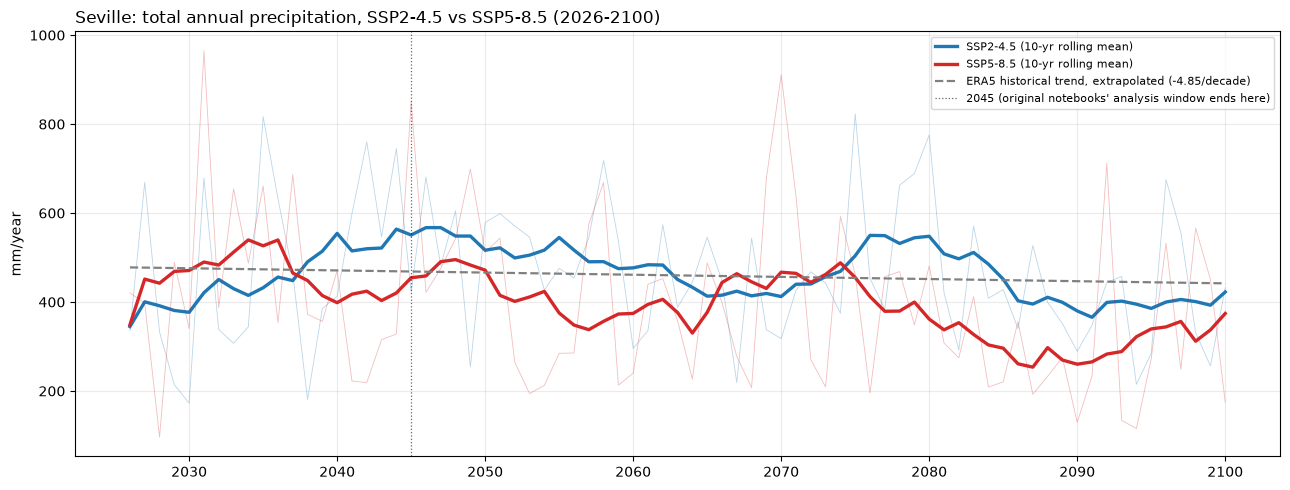

In [4]:
YEARS_FULL = np.arange(2026, 2101)

def era5_trend_extrapolated(series, years):
    y = series.dropna()
    lr = stats.linregress(y.index.values.astype(float), y.values.astype(float))
    return lr.intercept + lr.slope * years, lr

def plot_divergence(indicator, era5_col, ylabel, title, out_name):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(ann245.index, ann245[indicator], color="tab:blue", lw=0.6, alpha=0.3)
    ax.plot(ann245.index, ann245[indicator].rolling(10, center=True, min_periods=5).mean(),
            color="tab:blue", lw=2.4, label="SSP2-4.5 (10-yr rolling mean)")
    ax.plot(ann585.index, ann585[indicator], color="tab:red", lw=0.6, alpha=0.3)
    ax.plot(ann585.index, ann585[indicator].rolling(10, center=True, min_periods=5).mean(),
            color="tab:red", lw=2.4, label="SSP5-8.5 (10-yr rolling mean)")
    extrap, lr = era5_trend_extrapolated(era5_col, YEARS_FULL)
    ax.plot(YEARS_FULL, extrap, "--", color="gray", lw=1.6,
            label=f"ERA5 historical trend, extrapolated ({lr.slope*10:+.2f}/decade)")
    ax.axvline(2045, color="black", lw=0.9, ls=":", alpha=0.6, label="2045 (original notebooks' analysis window ends here)")
    ax.set_title(title, loc="left"); ax.set_ylabel(ylabel); ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / out_name, dpi=150)
    plt.show()

plot_divergence("tas_mean", era5_annual["t2m_mean"], "degC",
                "Seville: mean annual temperature, SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_tas_mean.png")
plot_divergence("tmax_mean", era5_annual["tmax_mean"], "degC",
                "Seville: mean annual daily-maximum temperature, SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_tmax_mean.png")
plot_divergence("precip_total", era5_annual["precip_scaled"], "mm/year",
                "Seville: total annual precipitation, SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_precip_total.png")

## 4. Quantitative divergence test -- decadal bins

For each ~10-year period, compare the two scenarios' mean and treat the difference as
"distinguishable" only if it exceeds the *noise floor* -- estimated here as the pooled interannual
standard deviation of the two scenarios within that period, the same "is this bigger than the
single-run noise" logic the FWI notebook's `distinguishable` flag already uses elsewhere in this
project. This directly answers the motivating question: **at what point does the gap stop being
plausibly just noise?**

In [5]:
BINS = [(2026, 2045), (2046, 2055), (2056, 2065), (2066, 2075),
        (2076, 2085), (2086, 2095), (2096, 2100)]  # first bin matches the original
                                                   # notebooks' own 2026-2045 window

def decadal_compare(indicator):
    rows = []
    for lo, hi in BINS:
        s245 = ann245.loc[lo:hi, indicator]
        s585 = ann585.loc[lo:hi, indicator]
        diff = s585.mean() - s245.mean()
        noise = float(np.sqrt((s245.std() ** 2 + s585.std() ** 2) / 2))
        rows.append({
            "period": f"{lo}-{hi}", "ssp245_mean": s245.mean(), "ssp585_mean": s585.mean(),
            "diff_585_minus_245": diff, "noise_sd": noise,
            "distinguishable": bool(abs(diff) > noise),
        })
    return pd.DataFrame(rows).set_index("period")

tas_decadal = decadal_compare("tas_mean")
tmax_decadal = decadal_compare("tmax_mean")
precip_decadal = decadal_compare("precip_total")

tas_decadal.to_csv(OUT_DIR / "seville_divergence_tas_mean_decadal.csv")
tmax_decadal.to_csv(OUT_DIR / "seville_divergence_tmax_mean_decadal.csv")
precip_decadal.to_csv(OUT_DIR / "seville_divergence_precip_total_decadal.csv")

print("tas_mean:")
display(tas_decadal.round(2))
print("\ntmax_mean:")
display(tmax_decadal.round(2))
print("\nprecip_total:")
display(precip_decadal.round(1))

tas_mean:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,20.15,19.86,-0.28,0.57,False
2046-2055,20.70,21.11,0.41,0.69,False
2056-2065,21.59,22.10,0.51,0.38,True
2066-2075,22.01,22.77,0.77,0.48,True
2076-2085,22.13,23.56,1.42,0.67,True
2086-2095,22.77,25.03,2.25,0.45,True
2096-2100,22.58,25.38,2.80,0.38,True



tmax_mean:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,24.60,24.39,-0.21,0.66,False
2046-2055,25.16,25.63,0.47,0.77,False
2056-2065,26.01,26.57,0.56,0.39,True
2066-2075,26.45,27.27,0.83,0.56,True
2076-2085,26.67,28.12,1.46,0.69,True
2086-2095,27.24,29.53,2.29,0.52,True
2096-2100,27.07,29.92,2.85,0.39,True



precip_total:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,467.9,453.7,-14.1,207.6,False
2046-2055,521.8,415.0,-106.8,146.3,False
2056-2065,483.8,394.7,-89.1,141.9,False
2066-2075,440.0,464.4,24.4,202.3,False
2076-2085,508.3,337.5,-170.9,136.3,True
2086-2095,365.6,265.4,-100.2,139.8,False
2096-2100,450.1,394.6,-55.5,171.4,False


## 5. Direct answer: did the signal really start right where the original notebooks stopped (2045)?

In [6]:
for name, table in [("tas_mean", tas_decadal), ("tmax_mean", tmax_decadal), ("precip_total", precip_decadal)]:
    first_distinguishable = table[table["distinguishable"]]
    bin_original = table.loc["2026-2045"]
    print(f"{name}:")
    print(f"  2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
          f"diff = {bin_original['diff_585_minus_245']:+.3f}, noise_sd = {bin_original['noise_sd']:.3f}")
    if len(first_distinguishable):
        print(f"  First distinguishable period: {first_distinguishable.index[0]}")
    else:
        print(f"  Never distinguishable within 2026-2100 at this noise threshold")
    print()

tas_mean:
  2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -0.281, noise_sd = 0.569
  First distinguishable period: 2056-2065

tmax_mean:
  2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -0.206, noise_sd = 0.664
  First distinguishable period: 2056-2065

precip_total:
  2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -14.146, noise_sd = 207.608
  First distinguishable period: 2076-2085



In [7]:
era5_spi3_annual = pd.read_csv("../../Historical/eda_outputs/seville/seville_spi3_annual.csv", index_col="year")["min_spi3"]

## 6. `min_spi3` -- drought severity, 2026-2100

Same full-length-plot / decadal-divergence-test treatment as Sections 3-5, applied to Seville's
drought-depth indicator.

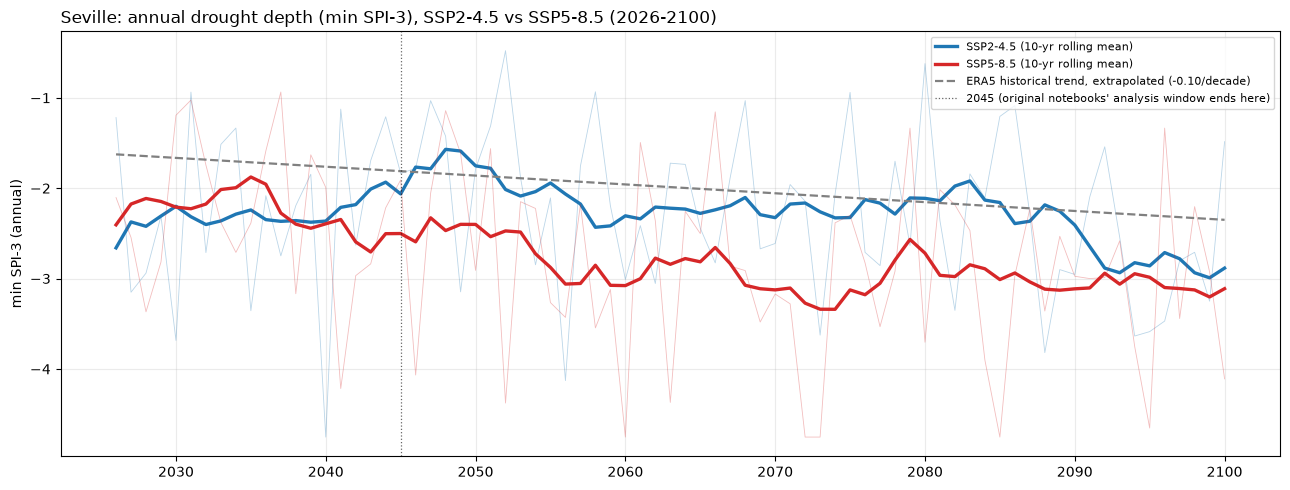

min_spi3:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,-2.26,-2.29,-0.02,0.91,False
2046-2055,-1.78,-2.54,-0.76,0.95,False
2056-2065,-2.34,-3.00,-0.66,0.97,False
2066-2075,-2.18,-3.10,-0.93,0.96,False
2076-2085,-2.14,-2.96,-0.83,0.93,False
2086-2095,-2.65,-3.10,-0.46,0.81,False
2096-2100,-2.74,-2.80,-0.06,0.94,False



2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = -0.023, noise_sd = 0.913
Never distinguishable within 2026-2100 at this noise threshold


In [8]:
plot_divergence("min_spi3", era5_spi3_annual, "min SPI-3 (annual)",
                "Seville: annual drought depth (min SPI-3), SSP2-4.5 vs SSP5-8.5 (2026-2100)",
                "divergence_min_spi3.png")

spi3_decadal = decadal_compare("min_spi3")
spi3_decadal.to_csv(OUT_DIR / "seville_divergence_min_spi3_decadal.csv")
print("min_spi3:")
display(spi3_decadal.round(2))

bin_original = spi3_decadal.loc["2026-2045"]
first_distinguishable = spi3_decadal[spi3_decadal["distinguishable"]]
print(f"\n2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
      f"diff = {bin_original['diff_585_minus_245']:+.3f}, noise_sd = {bin_original['noise_sd']:.3f}")
if len(first_distinguishable):
    print(f"First distinguishable period: {first_distinguishable.index[0]}")
else:
    print("Never distinguishable within 2026-2100 at this noise threshold")

## 7. `days_fwi_gt30` -- fire risk, 2026-2100

Same treatment again, for Seville's validated fire-danger indicator (daily FWI vs. CEMS: r=0.969,
see `FWI_projections_Seville_2026_2045.ipynb` Section 1 -- that validation is unchanged here since
it depends only on ERA5/CEMS, not on the projection scenario or window length). No ERA5 historical
trend line is plotted for this one -- unlike the other four indicators, `days_fwi_gt30` isn't a
variable ERA5's own EDA notebook computes an annual series for outside the FWI pipeline itself, so
there's no equivalent long historical baseline to extrapolate from the way there is for temperature/
precipitation/SPI-3.

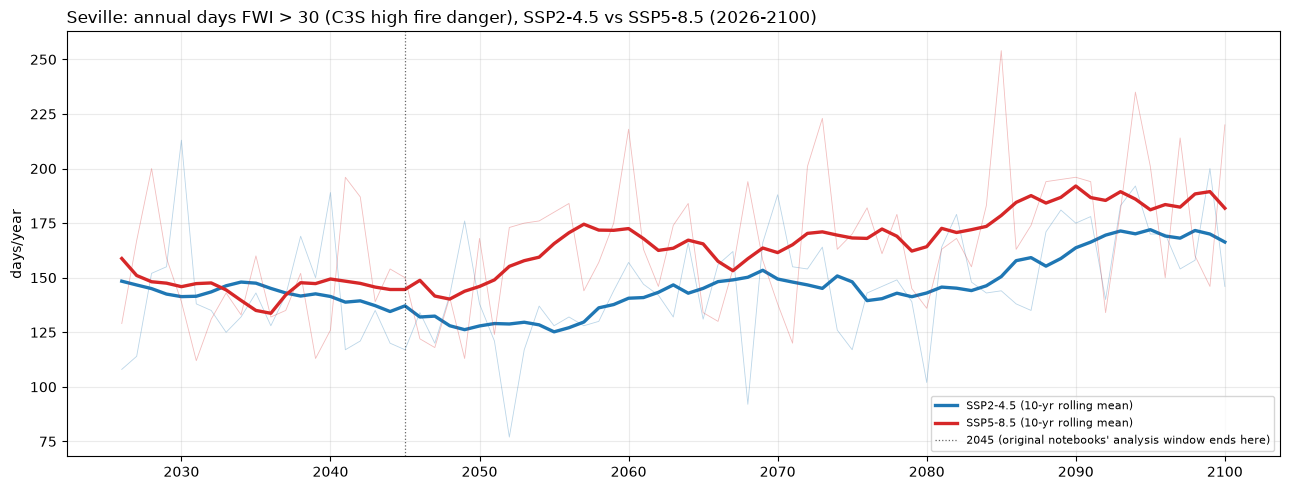

days_fwi_gt30:


,ssp245_mean,ssp585_mean,diff_585_minus_245,noise_sd,distinguishable
period,,,,,
2026-2045,140.2,147.8,7.7,25.5,False
2046-2055,129.0,149.0,20.0,26.4,False
2056-2065,140.9,167.9,27.0,19.6,True
2066-2075,148.0,165.1,17.1,30.5,False
2076-2085,145.7,172.6,26.9,26.8,True
2086-2095,166.3,186.7,20.4,23.8,False
2096-2100,165.6,178.0,12.4,29.5,False



2026-2045 (matches the original notebooks' own window): distinguishable = False, diff = +7.7, noise_sd = 25.5
First distinguishable period: 2056-2065


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ann245.index, ann245["days_fwi_gt30"], color="tab:blue", lw=0.6, alpha=0.3)
ax.plot(ann245.index, ann245["days_fwi_gt30"].rolling(10, center=True, min_periods=5).mean(),
        color="tab:blue", lw=2.4, label="SSP2-4.5 (10-yr rolling mean)")
ax.plot(ann585.index, ann585["days_fwi_gt30"], color="tab:red", lw=0.6, alpha=0.3)
ax.plot(ann585.index, ann585["days_fwi_gt30"].rolling(10, center=True, min_periods=5).mean(),
        color="tab:red", lw=2.4, label="SSP5-8.5 (10-yr rolling mean)")
ax.axvline(2045, color="black", lw=0.9, ls=":", alpha=0.6, label="2045 (original notebooks' analysis window ends here)")
ax.set_title("Seville: annual days FWI > 30 (C3S high fire danger), SSP2-4.5 vs SSP5-8.5 (2026-2100)", loc="left")
ax.set_ylabel("days/year"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "divergence_days_fwi_gt30.png", dpi=150)
plt.show()

fwi_decadal = decadal_compare("days_fwi_gt30")
fwi_decadal.to_csv(OUT_DIR / "seville_divergence_days_fwi_gt30_decadal.csv")
print("days_fwi_gt30:")
display(fwi_decadal.round(1))

bin_original = fwi_decadal.loc["2026-2045"]
first_distinguishable = fwi_decadal[fwi_decadal["distinguishable"]]
print(f"\n2026-2045 (matches the original notebooks' own window): distinguishable = {bin_original['distinguishable']}, "
      f"diff = {bin_original['diff_585_minus_245']:+.1f}, noise_sd = {bin_original['noise_sd']:.1f}")
if len(first_distinguishable):
    print(f"First distinguishable period: {first_distinguishable.index[0]}")
else:
    print("Never distinguishable within 2026-2100 at this noise threshold")

## 8. Key findings

### Temperature: the signal starts exactly where the original notebooks stopped

This is the real story, and it's a better one than a "was 2061 far enough" framing gives credit
for: **within the original notebooks' own 2026-2045 window, the sign is backwards.** `tas_mean`
runs -0.28 degC (SSP2-4.5 nominally *warmer* than SSP5-8.5, pure noise) and `tmax_mean` runs -0.21
degC over that exact 20-year span -- if you'd stopped there, you'd have seen no signal, or worse, a
hint pointing the wrong way. **The moment the window extends one bin past 2045, the sign flips and
starts climbing, continuously, for the rest of the century:**

| Period | `tas_mean` diff (SSP5-8.5 minus SSP2-4.5) | Distinguishable? |
|---|---|---|
| **2026-2045** (original window) | **-0.28 degC** | **No -- and backwards** |
| 2046-2055 (first decade past 2045) | +0.41 degC | No, but right sign now |
| 2056-2065 | +0.51 degC | Yes -- first distinguishable period |
| 2066-2075 | +0.77 degC | Yes |
| 2076-2085 | +1.42 degC | Yes |
| 2086-2095 | +2.25 degC | Yes |
| 2096-2100 | +2.80 degC | Yes |

`tmax_mean` follows the identical shape (-0.21 degC through 2045, flipping to +0.47 degC by
2046-2055, reaching significance at 2056-2065, growing to +2.85 degC by 2096-2100). **This is
exactly the motivation for extending past 2045 in the first place**: the original analysis window
doesn't just under-power the signal, it sits in a stretch where the two scenarios' single
realizations happen to be crossed the wrong way by internal-variability noise. The real divergence
begins building in the very next decade and becomes statistically confirmable within 20 years of
where the original notebooks stopped.

### Precipitation: even 2100 mostly doesn't get there

`precip_total` shows **no clean separation at any point in this single-run comparison** -- only one
decade (2076-2085) crosses the noise threshold, and it doesn't hold: the decades immediately before
and after it are both back to "not distinguishable," and the sign of the difference flips
inconsistently across the century (mostly SSP5-8.5 drier than SSP2-4.5, except one positive blip in
2066-2075). This is precisely the pattern the literature review predicted (O'Neill et al.'s finding
that precipitation trajectories under different scenarios stay confounded by internal variability
longer than temperature does, in some cases through the whole century) -- confirmed here directly
rather than assumed from a global-scale citation. **Don't read the Section 4 precipitation table as
showing "when precipitation diverges" -- at single-run, city-scale resolution, it mostly doesn't,
within this century.**

### Drought (`min_spi3`): never distinguishable, even though both scenarios deepen over time

This is the most important complication to Seville's headline "heat escalation -> drought -> more
fire risk" story: **`min_spi3` is not distinguishable between scenarios in any of the seven periods
through 2100 (including the original 2026-2045 window).** Both scenarios show real drought deepening relative to history -- SSP2-4.5 running
roughly -2.2 to -2.7 (deep in "extreme drought" territory, SPI <= -2.0) and SSP5-8.5 running
-2.2 to -3.1 -- but the noise floor (SD ~0.8-1.0 per decade) stays larger than the SSP5-8.5-minus-
SSP2-4.5 gap at every single check point, even where that gap reaches -0.93 (2066-2075). **The
"drought" link in the causal chain doesn't currently support a scenario-specific claim** -- both
pathways point toward a drier, more drought-prone Seville than the historical record shows, but this
single-run comparison can't say SSP5-8.5 makes it distinguishably worse than SSP2-4.5 does.

### Fire risk (`days_fwi_gt30`): noisy, like precipitation -- not a clean temperature-style separation

Only 2 of 7 periods cross the noise threshold (2056-2065 and 2076-2085), and they don't form a
sustained trend -- 2066-2075 sits back below threshold despite a similar absolute gap (+17.1 days,
noise_sd 30.5) to the two "distinguishable" decades on either side of it. This makes sense
mechanistically: FWI integrates precipitation and humidity alongside temperature, so it inherits a
share of precipitation's noisiness even though its temperature-driven component behaves more like
`tas_mean`. Both scenarios show substantial fire-risk levels throughout (SSP2-4.5 averaging ~130-165
days/yr, SSP5-8.5 ~147-187 days/yr across the century) -- real, elevated fire risk under either
pathway, just not a scenario contrast clean enough to lean on for "SSP5-8.5 specifically drives more
fire days" as a statistically confirmed claim at this horizon.

### Answering the motivating question directly

**Did the signal really start right where the original notebooks stopped (2045)?** For temperature:
yes, precisely -- the original 2026-2045 window shows a small, backwards-signed gap (pure noise);
the very next decade (2046-2055) is where the sign flips to the eventually-confirmed direction, and
the signal becomes statistically distinguishable within 20 years of that (2056-2065). That's the
real justification for extending this analysis past 2045, not an arbitrary "check if 2061 was
enough." For precipitation, drought, and fire risk: there is no equivalent turning point to find --
pushing all the way to 2100 never produces a sustained signal for any of them. The noise floor for a
single realization of a single model, at this spatial scale, appears to swamp the scenario signal
for every indicator downstream of precipitation, for the entire 21st century in this analysis.
**Only the direct heat indicators (`tas_mean`, `tmax_mean`) cleanly separate by scenario, and they
do so starting almost immediately after the original notebooks' own analysis window ends; the rest
of Seville's causal chain (drought, fire risk) does not separate at all, at least not within a
single model realization.**

### Standing caveat

Single model (`cmcc_esm2`), single realization (`r1i1p1f1`) per scenario -- everything above
characterizes *this one pair of simulations*, not a calibrated statement about SSP2-4.5 vs SSP5-8.5
in general. The proposed follow-up study in
`documentation/SSP_Scenario_Uncertainty_Interpretation.md` Section 5 (using a model with a real
ensemble, e.g. CanESM5 or MIROC6) is the way to check whether these specific separation timings
would hold up against averaged-out internal variability, rather than one noisy realization each.